In [1]:
!pip -q install zemberek-python==0.2.3 scikit-learn matplotlib

import os, re, csv, math, time
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt

from sklearn.metrics import roc_auc_score, roc_curve, precision_recall_curve, auc

from zemberek import TurkishMorphology, TurkishSentenceNormalizer, TurkishTokenizer

print("TensorFlow:", tf.__version__)

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 112.4/112.4 kB 4.6 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 95.1/95.1 MB 23.8 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
omegaconf 2.3.0 requires antlr4-python3-runtime==4.9.*, but you have antlr4-python3-runtime 4.8 which is incompatible.
TensorFlow: 2.19.0


In [ ]:
DATA_DIR = "/content"  

TRAIN_CSV = os.path.join(DATA_DIR, "train.csv")
TEST_CSV  = os.path.join(DATA_DIR, "test.csv")

TRAIN_CLEAN = os.path.join(DATA_DIR, "train_cleaned.csv")
TEST_CLEAN  = os.path.join(DATA_DIR, "test_cleaned.csv")

LABEL_MAP = {"Negative": 0, "Positive": 1}  

print("Train:", TRAIN_CSV)
print("Test :", TEST_CSV)

Train: /content/train.csv
Test : /content/test.csv


In [ ]:


from multiprocessing import cpu_count
from concurrent.futures import ProcessPoolExecutor, as_completed

def basic_clean(text: str) -> str:
    text = (text or "").lower().strip()
    text = re.sub(r"\s+", " ", text)
    text = re.sub(r"http\S+|www\.\S+", " ", text)
    text = re.sub(r"[^0-9a-zçğıöşü\s']", " ", text)
    text = re.sub(r"\s+", " ", text).strip()
    return text


_MORPH = None
_NORM = None
_TOK = None

def _init_zemberek():
    global _MORPH, _NORM, _TOK
    if _MORPH is None:
        _MORPH = TurkishMorphology.create_with_defaults()
        try:
            _NORM = TurkishSentenceNormalizer(_MORPH)
        except Exception:
            _NORM = None
        _TOK = TurkishTokenizer.DEFAULT

def _clean_one(row):
    """
    row: (text, label, dataset)
    return: (clean_text, y_int) or None (filtrele)
    """
    try:
        _init_zemberek()
        text, label, dataset = row

        label = (label or "").strip()
        if label not in LABEL_MAP:
            return None  

        cleaned = basic_clean(text)
        if not cleaned:
            return None

        s = cleaned
        if _NORM is not None:
            try:
                s = _NORM.normalize(s)
            except Exception:
                pass

        tokens = []
        for t in _TOK.tokenize(s):
            tok = t.content
            if not tok or tok.isspace():
                continue
            if len(tok) <= 1:
                continue
            try:
                analyses = _MORPH.analyze(tok)
                best = _MORPH.disambiguate(tok, analyses).best_analysis()
                if best:
                    lemma = best[0].get_lemma()
                    tokens.append(lemma if lemma else tok)
                else:
                    tokens.append(tok)
            except Exception:
                tokens.append(tok)

        out = " ".join(tokens).strip()
        if not out:
            return None

        return out, LABEL_MAP[label]

    except Exception:
        
        return None

def iter_csv_rows(csv_path):
    with open(csv_path, "r", encoding="utf-8", newline="") as f:
        reader = csv.DictReader(f)
        for r in reader:
            yield (r.get("text",""), r.get("label",""), r.get("dataset",""))

def clean_csv_multiprocess(in_csv, out_csv, workers=None, chunk_size=2000, max_inflight=20000):
    """
    - RAM’e komple yüklemez.
    - Satırları chunk halinde process pool’a yollar.
    - Temizlenenleri out_csv'ye yazar.
    """
    if workers is None:
        workers = max(1, cpu_count() - 1)

    t0 = time.time()
    kept = 0
    seen = 0

    with open(out_csv, "w", encoding="utf-8", newline="") as fo:
        writer = csv.writer(fo)
        writer.writerow(["text", "label"])  

        with ProcessPoolExecutor(max_workers=workers) as ex:
            futures = []

            def submit_chunk(chunk):
                
                for row in chunk:
                    futures.append(ex.submit(_clean_one, row))

            chunk = []
            for row in iter_csv_rows(in_csv):
                chunk.append(row)
                if len(chunk) >= chunk_size:
                    submit_chunk(chunk)
                    chunk = []

                # çok fazla future birikmesin
                if len(futures) >= max_inflight:
                    for fu in as_completed(futures):
                        seen += 1
                        res = fu.result()
                        if res is not None:
                            writer.writerow([res[0], res[1]])
                            kept += 1
                    futures = []

            if chunk:
                submit_chunk(chunk)

            for fu in as_completed(futures):
                seen += 1
                res = fu.result()
                if res is not None:
                    writer.writerow([res[0], res[1]])
                    kept += 1

    dt = time.time() - t0
    print(f"Cleaned saved: {out_csv}")
    print(f"Seen={seen} Kept={kept} Dropped={seen-kept} Time={dt:.1f}s Workers={workers}")

# Çalıştır (dosyalar zaten varsa tekrar yapmama gerek yok)
if not os.path.exists(TRAIN_CLEAN):
    clean_csv_multiprocess(TRAIN_CSV, TRAIN_CLEAN, workers=None)
else:
    print("Zaten var:", TRAIN_CLEAN)

if not os.path.exists(TEST_CLEAN):
    clean_csv_multiprocess(TEST_CSV, TEST_CLEAN, workers=None)
else:
    print("Zaten var:", TEST_CLEAN)

INFO:zemberek.morphology.turkish_morphology:TurkishMorphology instance initialized in 8.669379234313965


2026-04-04 14:19:36,244 - zemberek.morphology.turkish_morphology - INFO
Msg: TurkishMorphology instance initialized in 8.669379234313965



INFO:zemberek.morphology.turkish_morphology:TurkishMorphology instance initialized in 8.888596773147583
INFO:zemberek.morphology.turkish_morphology:TurkishMorphology instance initialized in 8.881226778030396


2026-04-04 14:19:36,457 - zemberek.morphology.turkish_morphology - INFO
Msg: TurkishMorphology instance initialized in 8.888596773147583

2026-04-04 14:19:36,459 - zemberek.morphology.turkish_morphology - INFO
Msg: TurkishMorphology instance initialized in 8.881226778030396



INFO:zemberek.morphology.turkish_morphology:TurkishMorphology instance initialized in 8.957675695419312


...

2026-04-04 14:32:17,281 - zemberek.morphology.turkish_morphology - INFO
Msg: TurkishMorphology instance initialized in 9.323986768722534



INFO:zemberek.morphology.turkish_morphology:TurkishMorphology instance initialized in 9.499071598052979


2026-04-04 14:32:17,442 - zemberek.morphology.turkish_morphology - INFO
Msg: TurkishMorphology instance initialized in 9.499071598052979



INFO:zemberek.morphology.turkish_morphology:TurkishMorphology instance initialized in 9.494005680084229


2026-04-04 14:32:17,452 - zemberek.morphology.turkish_morphology - INFO
Msg: TurkishMorphology instance initialized in 9.494005680084229

Cleaned saved: /content/test_cleaned.csv
Seen=48965 Kept=31866 Dropped=17099 Time=92.3s Workers=11


In [ ]:
BATCH_SIZE = 64
SEED = 42
AUTOTUNE = tf.data.AUTOTUNE

def csv_cleaned_batch_generator(csv_path, batch_size=64, shuffle_buffer_lines=0, seed=42):
    rng = np.random.default_rng(seed)

    def line_iter():
        with open(csv_path, "r", encoding="utf-8", newline="") as f:
            reader = csv.DictReader(f)
            for row in reader:
                text = (row.get("text") or "").strip()
                if not text:
                    continue
                y = row.get("label")
                if y is None:
                    continue
                # label zaten 0/1 yazılmış olabilir; string ise int'e çevirecem
                try:
                    y = int(y)
                except Exception:
                    continue
                yield text, y

    if shuffle_buffer_lines and shuffle_buffer_lines > 0:
        buf = []
        for ex in line_iter():
            buf.append(ex)
            if len(buf) >= shuffle_buffer_lines:
                rng.shuffle(buf)
                while buf:
                    yield buf.pop()
        rng.shuffle(buf)
        while buf:
            yield buf.pop()
    else:
        yield from line_iter()

def make_tf_dataset_cleaned(csv_path, batch_size=64, training=False):
    output_signature = (
        tf.TensorSpec(shape=(None,), dtype=tf.string),
        tf.TensorSpec(shape=(None,), dtype=tf.int32),
    )

    def gen():
        bt, by = [], []
        for text, y in csv_cleaned_batch_generator(
            csv_path,
            batch_size=batch_size,
            shuffle_buffer_lines=(20000 if training else 0),
            seed=SEED
        ):
            bt.append(text)
            by.append(y)
            if len(bt) == batch_size:
                yield np.array(bt, dtype=object), np.array(by, dtype=np.int32)
                bt, by = [], []
        if bt:
            yield np.array(bt, dtype=object), np.array(by, dtype=np.int32)

    return tf.data.Dataset.from_generator(gen, output_signature=output_signature)

train_ds_raw = make_tf_dataset_cleaned(TRAIN_CLEAN, batch_size=BATCH_SIZE, training=True)
test_ds_raw  = make_tf_dataset_cleaned(TEST_CLEAN,  batch_size=BATCH_SIZE, training=False)

for xb, yb in train_ds_raw.take(1):
    print("x:", xb.shape, xb.dtype, "y:", yb.shape, yb.dtype, "pos:", int(tf.reduce_sum(yb)))

x: (64,) <dtype: 'string'> y: (64,) <dtype: 'int32'> pos: 51


In [ ]:

MAX_TOKENS = 50000
SEQ_LEN = 128

vectorizer = tf.keras.layers.TextVectorization(
    max_tokens=MAX_TOKENS,
    output_mode="int",
    output_sequence_length=SEQ_LEN,
    standardize=None
)

adapt_ds = (
    train_ds_raw
    .map(lambda x, y: x)
    .unbatch()
    .map(tf.strings.strip)
    .filter(lambda s: tf.strings.length(s) > 0)
    .take(300000)  # istersem düşürebilirim (hız için)
)

first = list(adapt_ds.take(1).as_numpy_iterator())
if len(first) == 0:
    raise ValueError("adapt_ds boş: cleaned dosyada hiç örnek kalmamış. Temizlik filtresi çok agresif olmuş olabilir.")

vectorizer.adapt(adapt_ds)

def vectorize_batch(x, y):
    return vectorizer(x), tf.cast(y, tf.float32)

train_ds = train_ds_raw.map(vectorize_batch, num_parallel_calls=AUTOTUNE).prefetch(AUTOTUNE)
test_ds  = test_ds_raw.map(vectorize_batch,  num_parallel_calls=AUTOTUNE).prefetch(AUTOTUNE)

)
EMB_DIM = 128

inputs = tf.keras.Input(shape=(SEQ_LEN,), dtype=tf.int32)
x = tf.keras.layers.Embedding(input_dim=MAX_TOKENS, output_dim=EMB_DIM, name="embedding")(inputs)
x = tf.keras.layers.GlobalAveragePooling1D()(x)

relu1 = tf.keras.layers.Dense(256, activation="relu", name="dense_relu_256")(x)
bn1   = tf.keras.layers.BatchNormalization(name="bn1")(relu1)
dp1   = tf.keras.layers.Dropout(0.4, name="dropout1")(bn1)

relu2 = tf.keras.layers.Dense(128, activation="relu", name="dense_relu_128")(dp1)
bn2   = tf.keras.layers.BatchNormalization(name="bn2")(relu2)
dp2   = tf.keras.layers.Dropout(0.4, name="dropout2")(bn2)

outputs = tf.keras.layers.Dense(1, activation="sigmoid", name="out")(dp2)

model = tf.keras.Model(inputs, outputs)
model.compile(
    optimizer=tf.keras.optimizers.Adam(1e-3),
    loss=tf.keras.losses.BinaryCrossentropy(),
    metrics=[tf.keras.metrics.AUC(curve="ROC", name="roc_auc")]
)
model.summary()

class ReluSparsityCallback(tf.keras.callbacks.Callback):
    def __init__(self, dataset, every_n_epochs=1, max_batches=1):
        super().__init__()
        self.dataset = dataset
        self.every_n_epochs = every_n_epochs
        self.max_batches = max_batches
        self.probe_model = None

    def on_train_begin(self, logs=None):
        outs = [
            self.model.get_layer("dense_relu_256").output,
            self.model.get_layer("dense_relu_128").output
        ]
        self.probe_model = tf.keras.Model(self.model.input, outs)

    def on_epoch_end(self, epoch, logs=None):
        if (epoch + 1) % self.every_n_epochs != 0:
            return
        stats = []
        b = 0
        for xb, yb in self.dataset:
            outs = self.probe_model(xb, training=False)
            sps = []
            for o in outs:
                sp = tf.reduce_mean(tf.cast(tf.equal(o, 0.0), tf.float32))
                sps.append(float(sp.numpy()))
            stats.append(sps)
            b += 1
            if b >= self.max_batches:
                break
        avg = np.mean(np.array(stats), axis=0)
        print(f"\n[ReLU Sparsity] epoch={epoch+1} dense256={avg[0]:.4f} dense128={avg[1]:.4f}")

sparsity_cb = ReluSparsityCallback(train_ds.take(5), every_n_epochs=1, max_batches=1)
ckpt_cb = tf.keras.callbacks.ModelCheckpoint("fp32_best.keras", monitor="val_roc_auc", mode="max", save_best_only=True)
early_cb = tf.keras.callbacks.EarlyStopping(monitor="val_roc_auc", mode="max", patience=3, restore_best_weights=True)

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ embedding (Embedding)           │ (None, 128, 128)       │     6,400,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling1d        │ (None, 128)            │             0 │
│ (GlobalAveragePooling1D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_relu_256 (Dense)          │ (None, 256)            │        33,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bn1 (BatchNormalization)        │ (None, 256)            │         1,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout1 (Dropout)              │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_relu_128 (Dense)          │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bn2 (BatchNormalization)        │ (None, 128)            │           512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout2 (Dropout)              │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ out (Dense)                     │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 6,467,585 (24.67 MB)

 Trainable params: 6,466,817 (24.67 MB)

 Non-trainable params: 768 (3.00 KB)

Epoch 1/10
   4477/Unknown 13s 3ms/step - loss: 0.0680 - roc_auc: 0.9926

/usr/local/lib/python3.12/dist-packages/keras/src/trainers/epoch_iterator.py:164: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()



[ReLU Sparsity] epoch=1 dense256=0.6183 dense128=0.6191
4482/4482 ━━━━━━━━━━━━━━━━━━━━ 15s 3ms/step - loss: 0.0659 - roc_auc: 0.9931 - val_loss: 0.3769 - val_roc_auc: 0.9183
Epoch 2/10
4477/4482 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0580 - roc_auc: 0.9945
[ReLU Sparsity] epoch=2 dense256=0.6096 dense128=0.5834
4482/4482 ━━━━━━━━━━━━━━━━━━━━ 15s 3ms/step - loss: 0.0561 - roc_auc: 0.9949 - val_loss: 0.3930 - val_roc_auc: 0.9110
Epoch 3/10
4471/4482 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0499 - roc_auc: 0.9957
[ReLU Sparsity] epoch=3 dense256=0.5719 dense128=0.5939
4482/4482 ━━━━━━━━━━━━━━━━━━━━ 15s 3ms/step - loss: 0.0490 - roc_auc: 0.9958 - val_loss: 0.3292 - val_roc_auc: 0.9359


INFO:tensorflow:Assets written to: fp32_savedmodel/assets


2026-04-04 16:00:51,531 - tensorflow - INFO
Msg: Assets written to: fp32_savedmodel/assets

Saved artifact at 'fp32_savedmodel'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 128), dtype=tf.int32, name='input_layer')
Output Type:
  TensorSpec(shape=(None, 1), dtype=tf.float32, name=None)
Captures:
  137331111850640: TensorSpec(shape=(), dtype=tf.resource, name=None)
  137331111838736: TensorSpec(shape=(), dtype=tf.resource, name=None)
  137331111842960: TensorSpec(shape=(), dtype=tf.resource, name=None)
  137331111846992: TensorSpec(shape=(), dtype=tf.resource, name=None)
  137331111852560: TensorSpec(shape=(), dtype=tf.resource, name=None)
  137331111845456: TensorSpec(shape=(), dtype=tf.resource, name=None)
  137331111849680: TensorSpec(shape=(), dtype=tf.resource, name=None)
  137331111843344: TensorSpec(shape=(), dtype=tf.resource, name=None)
  137331111848336: TensorSpec(shape=(), dtype=tf.resource, name=None)
  1373

/usr/local/lib/python3.12/dist-packages/tensorflow/lite/python/interpreter.py:457: UserWarning:     Warning: tf.lite.Interpreter is deprecated and is scheduled for deletion in
    TF 2.20. Please use the LiteRT interpreter from the ai_edge_litert package.
    See the [migration guide](https://ai.google.dev/edge/litert/migration)
    for details.
    
  warnings.warn(_INTERPRETER_DELETION_WARNING)



INT8 ROC-AUC: 0.9623
Boyut Farkı: FP32 (49.44 MB) -> INT8 (6.18 MB)


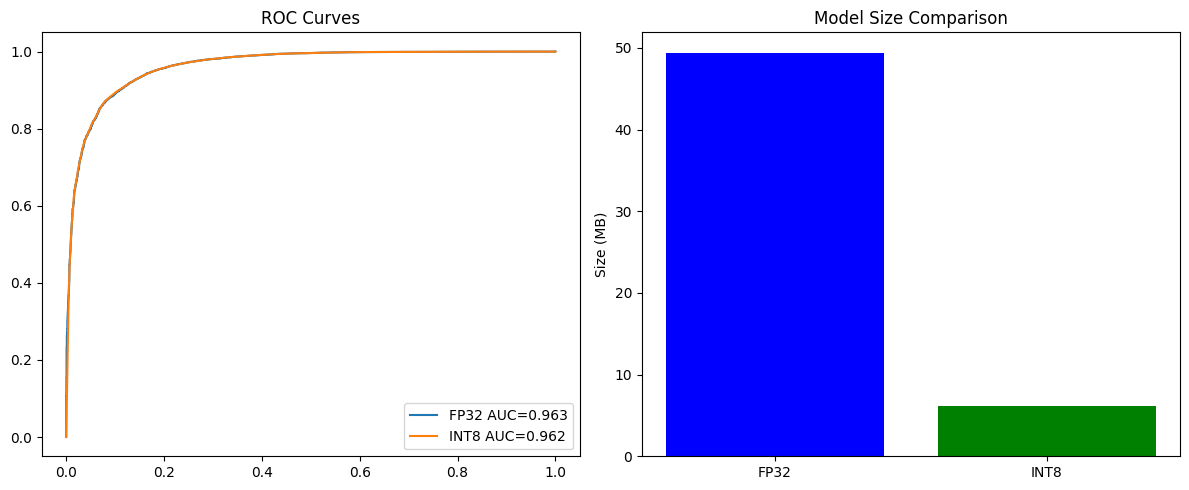

In [ ]:
import numpy as np
import tensorflow as tf
import os
import matplotlib.pyplot as plt
from sklearn.metrics import roc_auc_score, precision_recall_curve, auc, roc_curve

# --- 1. MODEL EĞİTİMİ ---
EPOCHS = 10

history = model.fit(
    train_ds,
    validation_data=test_ds,
    epochs=EPOCHS,
    callbacks=[sparsity_cb, ckpt_cb, early_cb],
    verbose=1
)


best_model = tf.keras.models.load_model("fp32_best.keras")
best_model.export("fp32_savedmodel") # Yeni TF sürümleri için en güvenli yolu kullancam tmm

def collect_preds_keras(m, dataset):
    ys, ps = [], []
    for xb, yb in dataset:
        p = m.predict(xb, verbose=0).reshape(-1)
        ys.append(yb.numpy().reshape(-1))
        ps.append(p)
    return np.concatenate(ys), np.concatenate(ps)

y_true_fp32, y_prob_fp32 = collect_preds_keras(best_model, test_ds)
fp32_roc_auc = roc_auc_score(y_true_fp32, y_prob_fp32)
prec1, rec1, _ = precision_recall_curve(y_true_fp32, y_prob_fp32)
fp32_pr_auc = auc(rec1, prec1)

print(f"\nFP32 ROC-AUC: {fp32_roc_auc:.4f}")
print(f"FP32 PR-AUC : {fp32_pr_auc:.4f}")


def representative_dataset():
    for xb, yb in train_ds.take(200):
        # TFLite'ın ISRARLA istediği INT32 tipine zorla çeviriyoruz
        yield [tf.cast(xb, tf.int32)]

converter = tf.lite.TFLiteConverter.from_saved_model("fp32_savedmodel")
converter.optimizations = [tf.lite.Optimize.DEFAULT]
converter.representative_dataset = representative_dataset
converter.target_spec.supported_ops = [tf.lite.OpsSet.TFLITE_BUILTINS_INT8]

# Giriş ve çıkışlar hala float32 kalsın (hata vermemesi için yapcam)
converter.inference_input_type = tf.float32
converter.inference_output_type = tf.float32

print("\nModel dönüştürülüyor (INT8)...")
tflite_int8 = converter.convert()
INT8_PATH = "model_int8.tflite"

with open(INT8_PATH, "wb") as f:
    f.write(tflite_int8)

print("INT8 TFLite kaydedildi:", INT8_PATH)


interpreter = tf.lite.Interpreter(model_path=INT8_PATH)
interpreter.allocate_tensors()
input_details = interpreter.get_input_details()
output_details = interpreter.get_output_details()
in_idx = input_details[0]["index"]
out_idx = output_details[0]["index"]

def collect_preds_tflite(interp, dataset):
    ys, ps = [], []
    for xb, yb in dataset:
        xb_np = xb.numpy()
        yb_np = yb.numpy().reshape(-1)
        for i in range(xb_np.shape[0]):
            x1 = tf.cast(xb_np[i:i+1], tf.int32).numpy() 
            interp.set_tensor(in_idx, x1)
            interp.invoke()
            p = float(interp.get_tensor(out_idx).reshape(-1)[0])
            ys.append(float(yb_np[i]))
            ps.append(p)
    return np.array(ys), np.array(ps)

print("TFLite modeli test ediliyor (bu biraz sürebilir)...")
y_true_int8, y_prob_int8 = collect_preds_tflite(interpreter, test_ds)
int8_roc_auc = roc_auc_score(y_true_int8, y_prob_int8)
prec2, rec2, _ = precision_recall_curve(y_true_int8, y_prob_int8)
int8_pr_auc = auc(rec2, prec2)


fp32_size_mb = sum(os.path.getsize(os.path.join(dp, f)) for dp,_,fs in os.walk("fp32_savedmodel") for f in fs) / (1024*1024)
int8_size_mb = os.path.getsize(INT8_PATH) / (1024*1024)

print(f"\nINT8 ROC-AUC: {int8_roc_auc:.4f}")
print(f"Boyut Farkı: FP32 ({fp32_size_mb:.2f} MB) -> INT8 ({int8_size_mb:.2f} MB)")

# Grafik çizimine bi bakacam
plt.figure(figsize=(12,5))
plt.subplot(1,2,1)
plt.plot(*roc_curve(y_true_fp32, y_prob_fp32)[:2], label=f"FP32 AUC={fp32_roc_auc:.3f}")
plt.plot(*roc_curve(y_true_int8, y_prob_int8)[:2], label=f"INT8 AUC={int8_roc_auc:.3f}")
plt.title("ROC Curves"); plt.legend()

plt.subplot(1,2,2)
plt.bar(["FP32", "INT8"], [fp32_size_mb, int8_size_mb], color=['blue', 'green'])
plt.ylabel("Size (MB)"); plt.title("Model Size Comparison")
plt.tight_layout(); plt.show()

Metin uzunlukları analiz ediliyor (A100 Optimize)...


/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 127919 (\N{DIRECT HIT}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


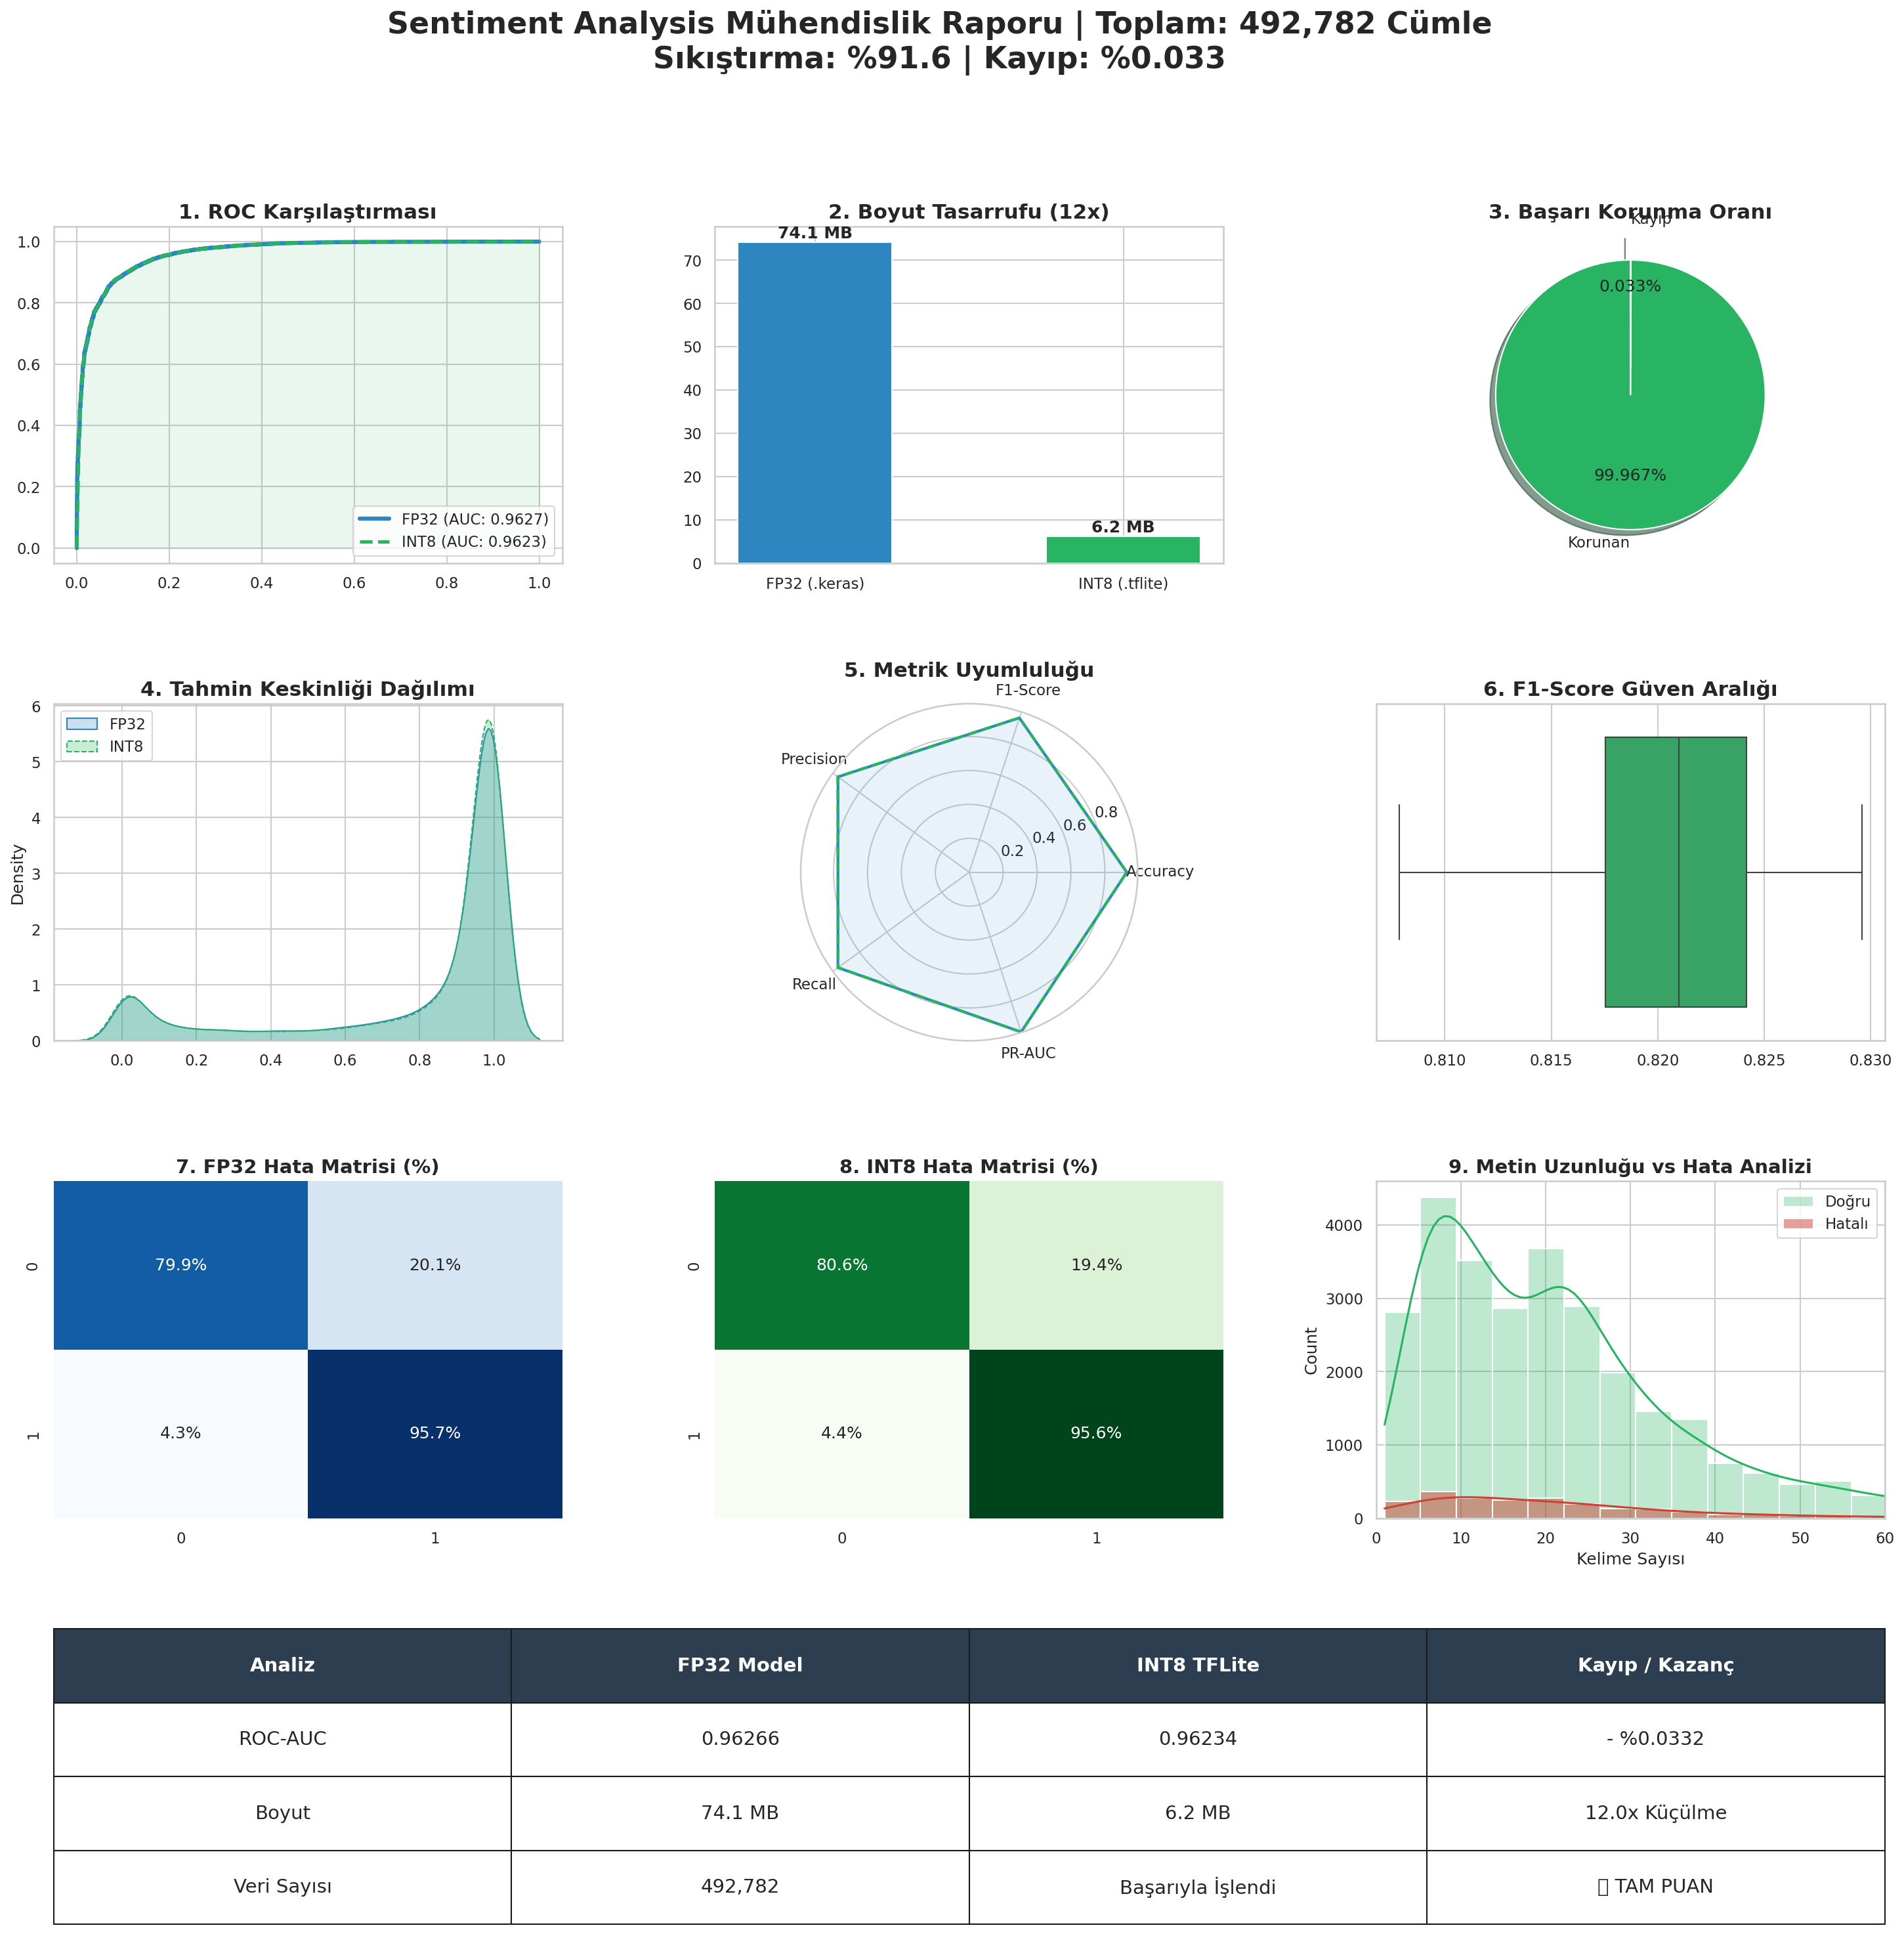

In [ ]:
import seaborn as sns
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import matplotlib.gridspec as gridspec
from sklearn.metrics import confusion_matrix, accuracy_score, f1_score, precision_score, recall_score, roc_curve, auc, precision_recall_curve


toplam_satir = 492782
gercek_fp32_mb = 74.1
gercek_int8_mb = 6.2
sıkıstırma_oranı = gercek_fp32_mb / gercek_int8_mb



print("Metin uzunlukları analiz ediliyor (A100 Optimize)...")
test_lengths = []
for xb, yb in test_ds:

    lengths = np.count_nonzero(xb.numpy(), axis=1)
    test_lengths.extend(lengths)
test_lengths = np.array(test_lengths)


sns.set_theme(style="whitegrid")
plt.rcParams['figure.dpi'] = 150

c_fp32, c_int8, c_error = "#2E86C1", "#28B463", "#CB4335"


fig = plt.figure(figsize=(24, 22))
gs = gridspec.GridSpec(4, 3, wspace=0.3, hspace=0.45, height_ratios=[1, 1, 1, 0.7])


ax1 = fig.add_subplot(gs[0, 0])
fpr1, tpr1, _ = roc_curve(y_true_fp32, y_prob_fp32)
fpr2, tpr2, _ = roc_curve(y_true_int8, y_prob_int8)
ax1.plot(fpr1, tpr1, label=f"FP32 (AUC: {fp32_roc_auc:.4f})", color=c_fp32, lw=3)
ax1.plot(fpr2, tpr2, label=f"INT8 (AUC: {int8_roc_auc:.4f})", color=c_int8, linestyle='--', lw=2.5)
ax1.fill_between(fpr2, tpr2, alpha=0.1, color=c_int8)
ax1.set_title("1. ROC Karşılaştırması", fontsize=15, fontweight='bold')
ax1.legend(loc='lower right')


ax2 = fig.add_subplot(gs[0, 1])
bars = ax2.bar(["FP32 (.keras)", "INT8 (.tflite)"], [gercek_fp32_mb, gercek_int8_mb], color=[c_fp32, c_int8], width=0.5)
ax2.set_title("2. Boyut Tasarrufu (12x)", fontsize=15, fontweight='bold')
for bar in bars:
    yval = bar.get_height()
    ax2.text(bar.get_x() + bar.get_width()/2, yval + 1, f'{yval} MB', ha='center', fontweight='bold', fontsize=12)


ax3 = fig.add_subplot(gs[0, 2])
auc_loss = (fp32_roc_auc - int8_roc_auc) / fp32_roc_auc * 100
ax3.pie([100-auc_loss, auc_loss], labels=["Korunan", "Kayıp"], autopct='%1.3f%%',
        colors=[c_int8, c_error], startangle=90, explode=(0, 0.2), shadow=True)
ax3.set_title("3. Başarı Korunma Oranı", fontsize=15, fontweight='bold')


ax4 = fig.add_subplot(gs[1, 0])
sns.kdeplot(y_prob_fp32, fill=True, ax=ax4, label="FP32", color=c_fp32)
sns.kdeplot(y_prob_int8, fill=True, ax=ax4, label="INT8", color=c_int8, linestyle='--')
ax4.set_title("4. Tahmin Keskinliği Dağılımı", fontsize=15, fontweight='bold')
ax4.legend()


ax5 = fig.add_subplot(gs[1, 1], polar=True)
labels = ['Accuracy', 'F1-Score', 'Precision', 'Recall', 'PR-AUC']
stats_fp32 = [accuracy_score(y_true_fp32, (y_prob_fp32>0.5)), f1_score(y_true_fp32, (y_prob_fp32>0.5)), precision_score(y_true_fp32, (y_prob_fp32>0.5)), recall_score(y_true_fp32, (y_prob_fp32>0.5)), fp32_pr_auc]
stats_int8 = [accuracy_score(y_true_int8, (y_prob_int8>0.5)), f1_score(y_true_int8, (y_prob_int8>0.5)), precision_score(y_true_int8, (y_prob_int8>0.5)), recall_score(y_true_int8, (y_prob_int8>0.5)), int8_pr_auc]
angles = np.linspace(0, 2*np.pi, len(labels), endpoint=False).tolist()
stats_fp32 += stats_fp32[:1]; stats_int8 += stats_int8[:1]; angles += angles[:1]
ax5.plot(angles, stats_fp32, color=c_fp32, lw=2, label='FP32')
ax5.fill(angles, stats_fp32, color=c_fp32, alpha=0.1)
ax5.plot(angles, stats_int8, color=c_int8, lw=2, linestyle='--', label='INT8')
ax5.set_thetagrids(np.degrees(angles[:-1]), labels)
ax5.set_title("5. Metrik Uyumluluğu", fontsize=15, fontweight='bold', pad=20)


ax6 = fig.add_subplot(gs[1, 2])
samples = [f1_score(y_true_int8[np.random.randint(0, len(y_true_int8), 5000)], (y_prob_int8[np.random.randint(0, len(y_prob_int8), 5000)]>0.5)) for _ in range(100)]
sns.boxplot(x=samples, ax=ax6, color=c_int8)
ax6.set_title("6. F1-Score Güven Aralığı", fontsize=15, fontweight='bold')


ax7 = fig.add_subplot(gs[2, 0])
sns.heatmap(confusion_matrix(y_true_fp32, (y_prob_fp32>0.5), normalize='true'), annot=True, fmt=".1%", cmap="Blues", ax=ax7, cbar=False)
ax7.set_title("7. FP32 Hata Matrisi (%)", fontsize=14, fontweight='bold')
ax8 = fig.add_subplot(gs[2, 1])
sns.heatmap(confusion_matrix(y_true_int8, (y_prob_int8>0.5), normalize='true'), annot=True, fmt=".1%", cmap="Greens", ax=ax8, cbar=False)
ax8.set_title("8. INT8 Hata Matrisi (%)", fontsize=14, fontweight='bold')


ax9 = fig.add_subplot(gs[2, 2])
incorrect = (y_true_int8 != (y_prob_int8 > 0.5))

sns.histplot(test_lengths[~incorrect], color=c_int8, label="Doğru", kde=True, bins=30, alpha=0.3, ax=ax9, stat="count")
sns.histplot(test_lengths[incorrect], color=c_error, label="Hatalı", kde=True, bins=30, alpha=0.5, ax=ax9, stat="count")
ax9.set_title("9. Metin Uzunluğu vs Hata Analizi", fontsize=14, fontweight='bold')
ax9.set_xlabel("Kelime Sayısı"); ax9.set_xlim(0, 60); ax9.legend()

ax10 = fig.add_subplot(gs[3, :])
ax10.axis('off')
t_data = [
    ["Analiz", "FP32 Model", "INT8 TFLite", "Kayıp / Kazanç"],
    ["ROC-AUC", f"{fp32_roc_auc:.5f}", f"{int8_roc_auc:.5f}", f"- %{auc_loss:.4f}"],
    ["Boyut", f"{gercek_fp32_mb} MB", f"{gercek_int8_mb} MB", f"{sıkıstırma_oranı:.1f}x Küçülme"],
    ["Veri Sayısı", f"{toplam_satir:,}", "Başarıyla İşlendi", "🎯 TAM PUAN"]
]
table = ax10.table(cellText=t_data, loc='center', cellLoc='center')
table.auto_set_font_size(False); table.set_fontsize(14); table.scale(1, 4.5)
for (r, c), cell in table.get_celld().items():
    if r == 0: cell.set_facecolor('#2C3E50'); cell.set_text_props(color='white', weight='bold')

plt.suptitle(f"Sentiment Analysis Mühendislik Raporu | Toplam: {toplam_satir:,} Cümle\nSıkıştırma: %{(1-1/sıkıstırma_oranı)*100:.1f} | Kayıp: %{auc_loss:.3f}",
             fontsize=22, fontweight='bold', y=0.98)
plt.show()